***
#### ***Jakub Wanat IAD***

# Zadanie rekrutacyjne do KN DataTeam 
### Celem jest analiza danych o mieszkaniach w Kalifornii i zbudowanie modelu regresji liniowej przewidującego cenę mieszkania (MedHouseVal), przy wykorzystaniu datasetu *fetch_california_housing* wbudowanego w bibliotekę scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
data = fetch_california_housing(as_frame=True)
df_raw = data.frame     # type: ignore - pylance error
df_raw.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


##### Kolumny:
- *MedInc* - median income in block
- *HouseAge* - median house age in block
- *AveRooms* - average number of rooms
- *AveBedrms* - average number of bedrooms
- *Population* - block population
- *AveOccup* - average house occupancy
- *Latitude* - house block latitude
- *Longitude* - house block longitude
- *MedHouseVal* - median house value  [5]


In [3]:
df_raw.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
print(df_raw.isnull().sum())
print(f'\n{df_raw.dtypes}')

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


#### Zbiór zawiera 20 640 obserwacji dotyczących sektorów mieszkaniowych w Kalifornii. Dane obejmują parametry ekonomiczne (dochód), demograficzne (populacja, obłożenie) oraz lokalizację geograficzną. Wszystkie kolumny są typu numerycznego (float64) oraz nie zaobserwowano wartości brakujących, co ułatwia bezpośrednie wykorzystanie ich w modelu regresji. Istotnym aspektem są jednak wartości odstające, widoczne w kolumnach dotyczących liczby i okupacji pokoi oraz populacji.

***
## Preprocessing danych

- ### Weryfikacja wartości odstających 

##### *Wykres 1: Boxploty wybranych cech.*


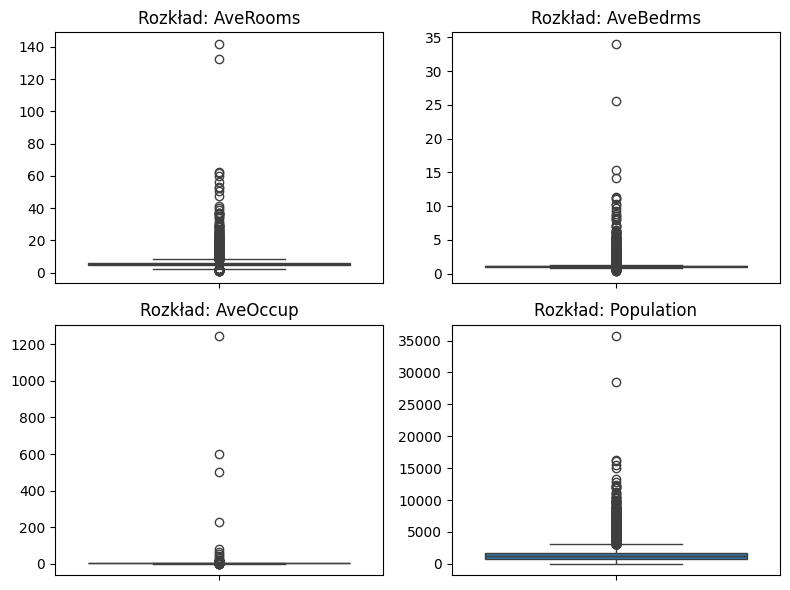

In [5]:
plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
sns.boxplot(df_raw['AveRooms'])
plt.title(f'Rozkład: AveRooms')
plt.ylabel('')

plt.subplot(2,2,2)
sns.boxplot(df_raw['AveBedrms'])
plt.title(f'Rozkład: AveBedrms')
plt.ylabel('')

plt.subplot(2,2,3)
sns.boxplot(df_raw['AveOccup'])
plt.title(f'Rozkład: AveOccup')
plt.ylabel('')

plt.subplot(2,2,4)
sns.boxplot(df_raw['Population'])
plt.title(f'Rozkład: Population')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### Wykresy pudełkowe obrazują rozkład danych i pozwalają zidentyfikować wartości odstające, widoczne jako punkty poza zakresem wąsów. Dzięki tej wizualizacji wiadomo, w których zmiennych konieczne jest przeprowadzenie filtrowania danych przed rozpoczęciem trenowania modelu.

##### *Wykres 2: Histogram rozkładu mediany wartości mieszkań (MedHouseVal).*

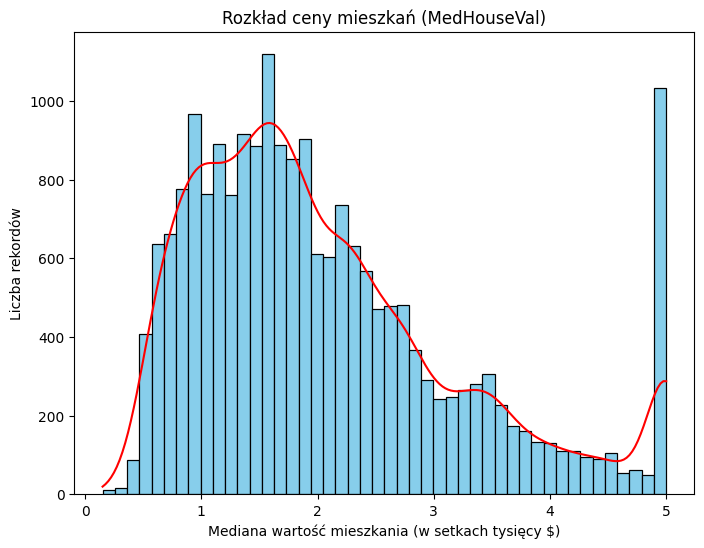

In [6]:
plt.figure(figsize=(8,6))
sns.histplot(df_raw['MedHouseVal'], kde=True, fc='skyblue', color='red')
plt.title('Rozkład ceny mieszkań (MedHouseVal)')
plt.xlabel('Mediana wartość mieszkania (w setkach tysięcy $)')
plt.ylabel('Liczba rekordów')
plt.show()

#### Wizualizacja pokazuje, jak często występują poszczególne przedziały cenowe w badanym regionie Kalifornii. Większość nieruchomości skupia się w okolicach wartości 1.0 - 2.5, jednak na samym końcu skali widać nienaturalny skok dla wartości 5.0. Oznacza to, że najdroższe domy zostały dopisane do jednej maksymalnej wartości, co może mieć wpływ na trenowanie modelu regresji.

#### 1) Usunięcie wartości odstających:

In [7]:
df = df_raw.copy()      # przetwarzanie na kopii danych

cols_to_fix = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))] # [1]

#### 2) Usunięcie ogona MedHouseVal:

In [8]:
df = df[df['MedHouseVal'] < 5.0]

#### 3) Feature Engineering, wprowadzenie cech złożonych:

In [9]:
df['BedrmsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['OccupPerRoom'] = df['AveOccup'] / df['AveRooms']
df.drop(columns=['AveRooms','AveBedrms','AveOccup'], inplace=True)

In [10]:
print(f'Dane po preprocessingu mają {len(df)} z {len(df_raw)} początkowych wierszy')
df.describe()

Dane po preprocessingu mają 16524 z 20640 początkowych wierszy


,MedInc,HouseAge,Population,Latitude,Longitude,MedHouseVal,BedrmsPerRoom,OccupPerRoom
count,16524.000000,16524.000000,16524.000000,16524.000000,16524.000000,16524.000000,16524.000000,16524.000000
mean,3.728397,29.367102,1275.485657,35.663378,-119.622856,1.962818,0.211354,0.576916
std,1.548503,12.224080,632.609418,2.137800,1.995250,0.979189,0.050722,0.192174
min,0.536000,1.000000,5.000000,32.540000,-124.350000,0.149990,0.113535,0.250000
25%,2.575475,19.000000,815.000000,33.930000,-121.820000,1.196000,0.176279,0.449570
50%,3.522700,30.000000,1160.500000,34.280000,-118.580000,1.795000,0.202215,0.521739
75%,4.645800,38.000000,1640.000000,37.730000,-118.030000,2.539250,0.237345,0.647268
max,15.000100,52.000000,3176.000000,41.950000,-114.570000,4.991000,0.564854,1.913596


***
## Analiza oraz wizualizacja zależności między cechami a ceną mieszkań (MedHouseVal).

##### *Wykres 3: Mapa korelacji zmiennych zestawu California Housing. [3]*

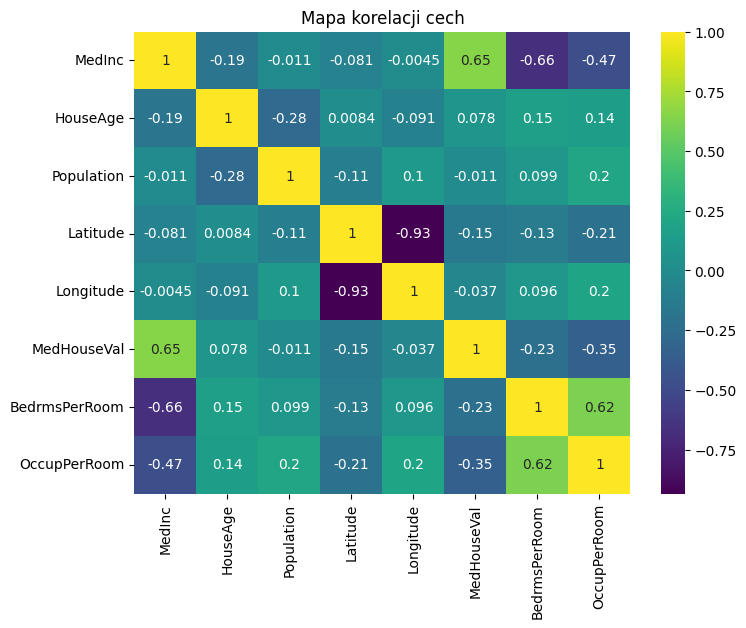

In [11]:
plt.figure(figsize=(8,6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='viridis', annot=True)
plt.title('Mapa korelacji cech')
plt.show()

#### Wykres wskazuje na bardzo silną zależność dodatnią między medianą dochodów **(MedInc)** a ceną nieruchomości **(MedHouseVal)**, co czyni dochód głównym predyktorem. Zauważalna jest również wysoka korelacja między stosunkiem sypialni na liczbę pokojów **(BedrmsPerRooms)** a medianą dochodów **(MedInc)**, między stosunkiem lokatorów na liczbę pokojów **(OccupPerRoom)** a medianą dochodów **(MedInc)** oraz między stosunkiem sypialni na pokoje **(BedrmsPerRooms)** a stosunkiem lokatorów na liczbę pokojów **(OccupPerRoom)**. Dla innych cech nie stwierdzono istotnych zależności .



##### *Wykres 4: Rozkład geograficzny mieszkań z uwzględnieniem ich wartości.*

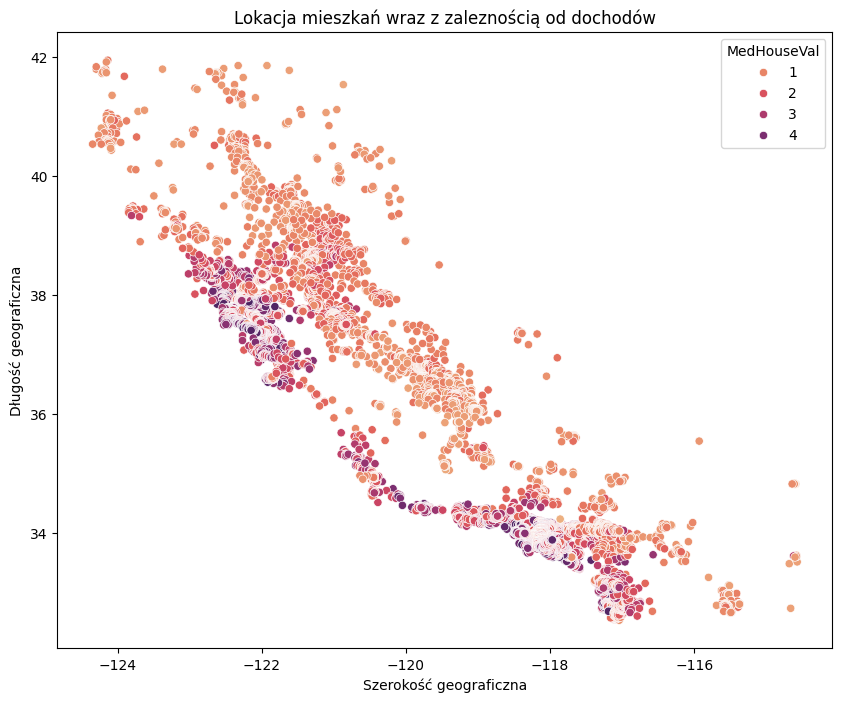

In [12]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=df['Longitude'], y=df['Latitude'], hue=df['MedHouseVal'], palette='flare') # [2]
plt.title('Lokacja mieszkań wraz z zaleznością od dochodów')
plt.xlabel('Szerokość geograficzna')
plt.ylabel('Długość geograficzna')
plt.show()

#### Punkty na wykresie odzwierciedlają mapę Kalifornii, gdzie intensywność koloru oznacza wartość. Najwyższe ceny (odcienie fioletu) koncentrują się wzdłuż wybrzeża oraz dużych miast, szczególnie w okolicach San Francisco i Los Angeles. Wizualizacja ta potwierdza, że lokalizacja i bliskość oceanu drastycznie wpływają na wzrost wartości nieruchomości.

##### *Wykres 5: Zależność mediany wartości mieszkań od mediany dochodów.*

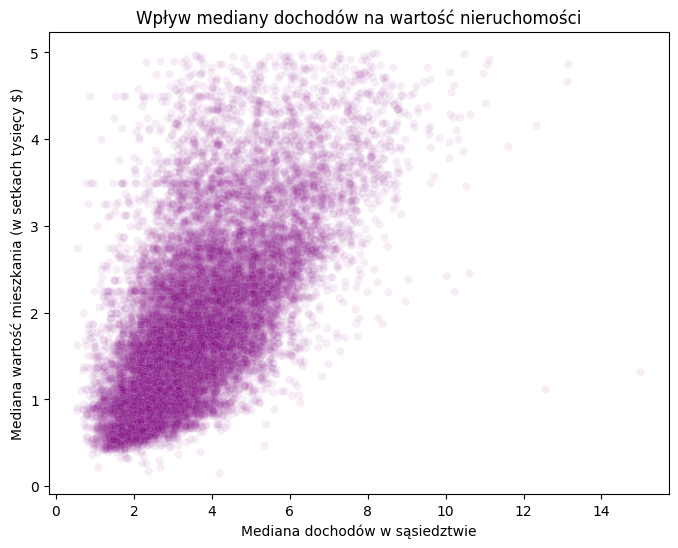

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot( x=df['MedInc'], y=df['MedHouseVal'], alpha=0.07, color='purple')
plt.title('Wpływ mediany dochodów na wartość nieruchomości')
plt.xlabel('Mediana dochodów w sąsiedztwie')
plt.ylabel('Mediana wartość mieszkania (w setkach tysięcy $)')
plt.show()

#### Z wykresu wynika jednoznaczny trend rosnący pomiędzy medianą zarobków w danej okolicy a wyceną nieruchomości. Największe zagęszczenie danych (najciemniejsze obszary) występuje dla dochodów rzędu 20 000 – 60 000$ rocznie, co bezpośrednio przekłada się na ceny mieszkań w przedziale od 100 000 - 250 000$. Potwierdza to regułę: im zamożniejsi są mieszkańcy danej okolicy, tym wyższa staje się wartość tamtejszych nieruchomości.

***
### Przygotowanie modelu regresji liniowej.

#### 1) Definicja zmienne objaśniające (X) i zmienną celu (y):


In [14]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

#### 2) Podział na zbiór treningowy i testowy (test = 25% * train):

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'Rozmiar zbioru treningowego: {X_train.shape}')
print(f'Rozmiar zbioru testowego: {X_test.shape}')

Rozmiar zbioru treningowego: (12393, 7)
Rozmiar zbioru testowego: (4131, 7)


#### 3) Inicjalizacja, nauka oraz predykcja modelu:

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### 4) Ewaluacja modelu:

#### Uzasadnienie doboru metryk:
#### Dobór tych wskaźników pozwali ocenić model z różnych perspektyw. **MAE** informuje o przeciętnym błędzie w dolarach, co daje jasny obraz precyzji, natomiast **RMSE** uwidacznia średnią różnicę między wartościami przewidzianymi a rzeczywistymi. Współczynnik **R^2** służy jako miara dopasowania, wskazuje jak dużą część rzeczywistych różnic w cenach mieszkań udało się poprawnie wyjaśnić za pomocą zbudowanego modelu. [4]

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Pierwiastek błędu średniokwadratowego (RMSE): {rmse:.4f}')
print(f'Błąd średni bezwzględny (MAE): {mae:.4f}')
print(f'Współczynnik determinacji (R^2): {r2:.4f}')

Pierwiastek błędu średniokwadratowego (RMSE): 0.5822
Błąd średni bezwzględny (MAE): 0.4312
Współczynnik determinacji (R^2): 0.6516


### Wnioski z obliczonych metryk:
- #### Uzyskane wyniki pozwalają na obiektywną ocenę jakości przewidywań modelu. MAE wskazuje, że średnio model myli się o około **0.43** (czyli ok. 43 000$), co przy cenach nieruchomości jest wynikiem akceptowalnym dla badanego regionu. 

- #### Wyższa wartość RMSE (**0.58**) sugeruje, że w zbiorze wciąż występują pojedyncze oferty z większymi błędami predykcji. 

- #### Współczynnik R^2 wynoszący około **0.65** potwierdza, że nasze zmienne objaśniają znaczną większość trendów rynkowych, choć pozostawiają margines na bardziej zaawansowane algorytmy.

*** 
## Wnioski końcowe:
### Przeprowadzona analiza pozwoliła na skuteczne zidentyfikowanie głównych czynników kształtujących ceny mieszkań w Kalifornii. Kluczowym wnioskiem jest dominujący wpływ mediany dochodów mieszkańców na wartość nieruchomości, co w połączeniu z lokacją (bliskość wybrzeża i dużych metropolii) stanowią fundamenty wyceny mieszkań.

### Usunięcie wartości odstających oraz uciętego zakresu cen powyżej 5.0 pozwoliło modelowi skupić się na rzeczywistych trendach rynkowych, unikając błędów wynikających z podatności modelu regresji liniowej. 

### Pomimo prostoty regresji liniowej, osiągnięte rezultaty stanowią solidny fundament do dalszych prac, np. z wykorzystaniem modeli nieliniowych lub dodaniu większej ilość badanych cech (np. stan mieszkania). 

***
### Bibliografia
- [1] https://medium.com/analytics-vidhya/removing-outliers-understanding-how-and-what-behind-the-magic-18a78ab480ff
- [2] https://seaborn.pydata.org/tutorial/color_palettes.html
- [3] https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots
- [4] https://rpubs.com/mmazurek/320600#:~:text=Weryfikacja%20za%C5%82o%C5%BCe%C5%84%20regresji%20liniowej.%20Warto%C5%9Bci%20resztowe%20(residuals).,%23%23%20%2D3.4857935%20%2D0.3385256%20%2D3.8157146%20%2D3.8844494%20%2D4.0551322%20%2D6.3046111
- [5] https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html